In [1]:
import dnnlib.nlb_util_v2 as nlb_util
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
out_dir = "data"

# 1. dmfc_rsg

In [3]:
train_loader,val_loader,train_data,val_data,metadata = nlb_util.make_dmfc_rsg_loaders()

/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/pandas/core/arrays/timedeltas.py:1004: RuntimeWarning: invalid value encountered in cast
  base = data.astype(np.int64)
/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/pandas/core/arrays/timedeltas.py:1008: RuntimeWarning: invalid value encountered in cast
  data = (base * m + (frac * m).astype(np.int64)).view("timedelta64[ns]")


done!
smoothing spikes with 8ms gaussian window...
done!


separating into trials: 100%|███████████████| 1160/1160 [00:17<00:00, 66.93it/s]


In [4]:
len(train_data)

748

In [5]:
pd.DataFrame(train_data[0])

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.049904,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.049131,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.047619,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.045438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042685,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2962,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.055091,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024704,0.0
2963,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054474,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.028435,0.0
2964,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.053354,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.032221,0.0
2965,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.051694,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.035945,0.0


In [6]:
# calculate mean & stds over all trial within training
train_all = np.concatenate(train_data, axis=0)
means = np.mean(train_all, axis=0)  # Per dimension
stds = np.std(train_all, axis=0)
stds = np.maximum(stds, 1e-8)

In [7]:
for i in range(len(train_data)): train_data[i] = (train_data[i] - means) / stds
for i in range(len(val_data)): val_data[i] = (val_data[i] - means) / stds

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,1.828884,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,-0.626814,-0.314434
1,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,1.787572,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,-0.626814,-0.314434
2,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,1.706861,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,-0.626814,-0.314434
3,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,1.590426,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,-0.626814,-0.314434
4,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,1.443430,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,-0.626814,-0.314434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2962,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,2.105819,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,0.553889,-0.314434
2963,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,2.072892,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,0.732167,-0.314434
2964,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,2.013071,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,0.913113,-0.314434
2965,-0.304837,-0.733374,-0.204329,-0.232764,-0.279543,-0.147714,-0.186503,-0.246089,-0.250927,1.924449,...,-0.136933,-0.437505,-0.095157,-0.203588,-0.352135,-0.229494,-0.165786,-0.8579,1.091098,-0.314434


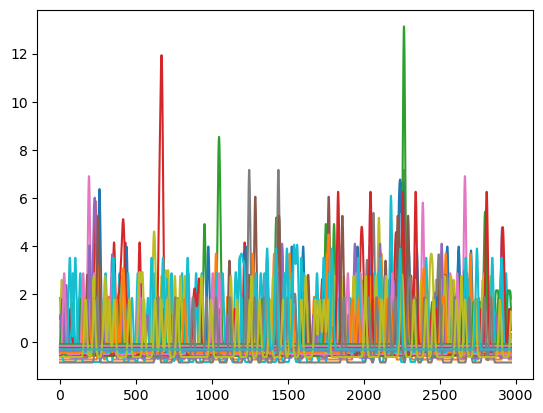

In [8]:
trial_id = 0
plt.plot(train_data[trial_id]);
pd.DataFrame(train_data[trial_id])

In [9]:
sub_dir = os.path.join(out_dir, "dmfc_rsg")
os.makedirs(sub_dir, exist_ok=True)
save_path = os.path.join(sub_dir, "dataset_samples.npz")
np.savez(save_path, samples=np.array(train_data, dtype=object))

# 2. mc_rtt

In [10]:
train_loader,val_loader,train_data,val_data,metadata = nlb_util.make_mc_rtt_loaders()

loading mc_rtt data...
done!
smoothing spikes with 8ms gaussian window...
done!


separating into trials: 100%|██████████████| 1080/1080 [00:03<00:00, 302.03it/s]


In [11]:
len(train_data)

810

In [12]:
pd.DataFrame(train_data[0])

,0,1,2,3,4,5,6,7,8,9,...,88,89,90,91,92,93,94,95,96,97
0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.005960,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.007653,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.009674,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.012040,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.000000,0.0,0.014752,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.0,0.0,0.0,0.028435,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.028435,0.0,0.042685,0.0,0.032221,0.028435,0.0,0.0
596,0.0,0.0,0.0,0.024704,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.024704,0.0,0.045438,0.0,0.028435,0.024704,0.0,0.0
597,0.0,0.0,0.0,0.021131,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.021131,0.0,0.047619,0.0,0.024704,0.021131,0.0,0.0
598,0.0,0.0,0.0,0.017794,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.017794,0.0,0.049131,0.0,0.021131,0.017794,0.0,0.0


In [13]:
# calculate mean & stds over all trial within training
train_all = np.concatenate(train_data, axis=0)
means = np.mean(train_all, axis=0)  # Per dimension
stds = np.std(train_all, axis=0)
stds = np.maximum(stds, 1e-8)

In [14]:
for i in range(len(train_data)): train_data[i] = (train_data[i] - means) / stds
for i in range(len(val_data)): val_data[i] = (val_data[i] - means) / stds

,0,1,2,3,4,5,6,7,8,9,...,88,89,90,91,92,93,94,95,96,97
0,-0.521687,-0.290147,-0.18213,-0.527785,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,-0.441510,-0.32827,-0.289339,-0.349633,-0.115461,-0.581280,-0.259706,-0.231518
1,-0.521687,-0.290147,-0.18213,-0.527785,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,-0.441510,-0.32827,-0.289339,-0.349633,-0.010373,-0.581280,-0.259706,-0.231518
2,-0.521687,-0.290147,-0.18213,-0.527785,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,-0.441510,-0.32827,-0.289339,-0.349633,0.115104,-0.581280,-0.259706,-0.231518
3,-0.521687,-0.290147,-0.18213,-0.527785,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,-0.441510,-0.32827,-0.289339,-0.349633,0.261952,-0.581280,-0.259706,-0.231518
4,-0.521687,-0.290147,-0.18213,-0.527785,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,-0.441510,-0.32827,-0.289339,-0.349633,0.430287,-0.581280,-0.259706,-0.231518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,-0.521687,-0.290147,-0.18213,1.161801,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,1.475800,-0.32827,3.857822,-0.349633,1.514708,0.852997,-0.259706,-0.231518
596,-0.521687,-0.290147,-0.18213,0.940153,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,1.224278,-0.32827,4.125291,-0.349633,1.279683,0.664841,-0.259706,-0.231518
597,-0.521687,-0.290147,-0.18213,0.727809,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,0.983314,-0.32827,4.337153,-0.349633,1.048124,0.484584,-0.259706,-0.231518
598,-0.521687,-0.290147,-0.18213,0.529531,-0.064372,-0.363607,-0.294091,-0.225368,-0.339019,-0.227527,...,-0.401024,-0.434926,0.758312,-0.32827,4.484014,-0.349633,0.826285,0.316268,-0.259706,-0.231518


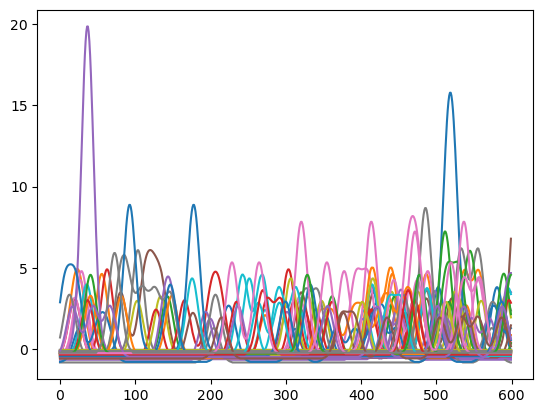

In [15]:
trial_id = 0
plt.plot(train_data[trial_id]);
pd.DataFrame(train_data[trial_id])

In [16]:
sub_dir = os.path.join(out_dir, "mc_rtt")
os.makedirs(sub_dir, exist_ok=True)
save_path = os.path.join(sub_dir, "dataset_samples.npz")
np.savez(save_path, samples=np.array(train_data, dtype=object))

# 3. area2_bump_with_behavior

In [17]:
train_loader,val_loader,train_data,val_data,metadata = nlb_util.loader_area2_bump_with_behavior()

/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/pandas/core/arrays/timedeltas.py:1004: RuntimeWarning: invalid value encountered in cast
  base = data.astype(np.int64)
/home/ganchao/miniconda3/envs/vfm/lib/python3.9/site-packages/pandas/core/arrays/timedeltas.py:1008: RuntimeWarning: invalid value encountered in cast
  data = (base * m + (frac * m).astype(np.int64)).view("timedelta64[ns]")
/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/dnnlib/nlb_util_v2.py:140: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  smoothed_spikes['time_stamp'] = smoothed_spikes.index.total_seconds()


In [18]:
len(train_data)

272

In [19]:
train_data[1].shape

(3221, 49)

In [20]:
pd.DataFrame(train_data[0])

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,0.009526,0.0,0.0,0.0,0.0,0.0,0.008248,0.007097,0.000000,0.013627,...,0.009777,0.0,0.001973,0.008880,0.0,0.0,0.0,0.029949,0.005237,0.000000
1,0.009549,0.0,0.0,0.0,0.0,0.0,0.008054,0.007085,0.000000,0.013331,...,0.009826,0.0,0.002074,0.008986,0.0,0.0,0.0,0.029795,0.005386,0.000000
2,0.009574,0.0,0.0,0.0,0.0,0.0,0.007861,0.006968,0.000000,0.013032,...,0.009869,0.0,0.002178,0.009088,0.0,0.0,0.0,0.029531,0.005536,0.000000
3,0.009601,0.0,0.0,0.0,0.0,0.0,0.007668,0.006853,0.000000,0.012733,...,0.009906,0.0,0.002287,0.009185,0.0,0.0,0.0,0.029378,0.005687,0.000000
4,0.009630,0.0,0.0,0.0,0.0,0.0,0.007476,0.006739,0.000000,0.012432,...,0.009937,0.0,0.002399,0.009277,0.0,0.0,0.0,0.029221,0.005838,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5417,0.000000,0.0,0.0,0.0,0.0,0.0,0.017399,0.019885,0.024164,0.015835,...,0.000000,0.0,0.004226,0.016785,0.0,0.0,0.0,0.021258,0.000513,0.018641
5418,0.000000,0.0,0.0,0.0,0.0,0.0,0.017409,0.019416,0.023922,0.016148,...,0.000000,0.0,0.004366,0.016858,0.0,0.0,0.0,0.021349,0.000545,0.018403
5419,0.000000,0.0,0.0,0.0,0.0,0.0,0.017416,0.018951,0.023680,0.016459,...,0.000000,0.0,0.004507,0.016925,0.0,0.0,0.0,0.021436,0.000578,0.018161
5420,0.000000,0.0,0.0,0.0,0.0,0.0,0.017422,0.018490,0.023436,0.016767,...,0.000000,0.0,0.004650,0.016984,0.0,0.0,0.0,0.021518,0.000614,0.017916


In [21]:
# calculate mean & stds over all trial within training
train_all = np.concatenate(train_data, axis=0)
means = np.mean(train_all, axis=0)  # Per dimension
stds = np.std(train_all, axis=0)
stds = np.maximum(stds, 1e-8)

In [22]:
for i in range(len(train_data)): train_data[i] = (train_data[i] - means) / stds
for i in range(len(val_data)): val_data[i] = (val_data[i] - means) / stds

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,1.767906,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,-0.186432,-0.163848,-0.481698,1.772770,...,0.871120,-0.240081,-0.030629,0.403086,-0.468843,-0.181505,-0.284874,2.304999,1.623205,-0.718848
1,1.772858,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,-0.205573,-0.165066,-0.481698,1.717482,...,0.878681,-0.240081,-0.008758,0.415367,-0.468843,-0.181505,-0.284874,2.289965,1.677560,-0.718848
2,1.778353,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,-0.224656,-0.177633,-0.481698,1.661891,...,0.885327,-0.240081,0.013956,0.427137,-0.468843,-0.181505,-0.284874,2.264092,1.732206,-0.718848
3,1.784366,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,-0.243667,-0.190042,-0.481698,1.606072,...,0.891047,-0.240081,0.037527,0.438376,-0.468843,-0.181505,-0.284874,2.249106,1.787081,-0.718848
4,1.790867,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,-0.262590,-0.202262,-0.481698,1.550100,...,0.895830,-0.240081,0.061971,0.449064,-0.468843,-0.181505,-0.284874,2.233750,1.842123,-0.718848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5417,-0.331587,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,0.715692,1.207833,5.181295,2.184056,...,-0.637150,-0.240081,0.459166,1.318257,-0.468843,-0.181505,-0.284874,1.454488,-0.095790,0.838002
5418,-0.331587,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,0.716679,1.157572,5.124675,2.242399,...,-0.637150,-0.240081,0.489515,1.326770,-0.468843,-0.181505,-0.284874,1.463473,-0.084130,0.818117
5419,-0.331587,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,0.717450,1.107702,5.067775,2.300304,...,-0.637150,-0.240081,0.520254,1.334459,-0.468843,-0.181505,-0.284874,1.471955,-0.071872,0.797936
5420,-0.331587,-0.269178,-0.21641,-0.182629,-0.340493,-0.245082,0.718008,1.058251,5.010600,2.357715,...,-0.637150,-0.240081,0.551356,1.341317,-0.468843,-0.181505,-0.284874,1.479940,-0.058996,0.777472


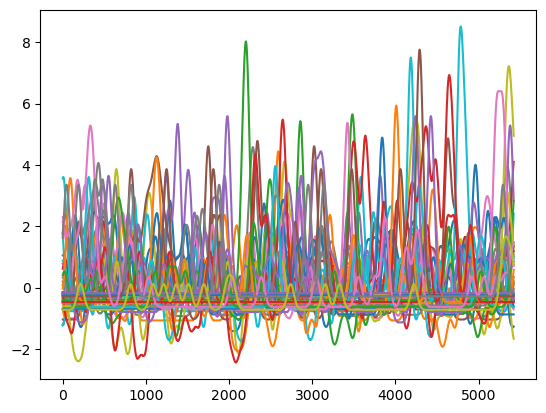

In [23]:
trial_id = 0
plt.plot(train_data[trial_id]);
pd.DataFrame(train_data[trial_id])

In [24]:
sub_dir = os.path.join(out_dir, "area2_bump_with_behavior")
os.makedirs(sub_dir, exist_ok=True)
save_path = os.path.join(sub_dir, "dataset_samples.npz")
np.savez(save_path, samples=np.array(train_data, dtype=object))

# 4. mc_maze_with_behavior

forget about it now, contains tooooo many NaNs.